## 📦 Importing Libraries

In this step, we import the necessary Python libraries required for data analysis.


In [470]:
# Import 
import pandas as pd
import matplotlib.pyplot as plt

## 📂 Data Loading

In this step, the dataset is loaded into a pandas DataFrame.

A DataFrame is a tabular data structure (similar to Excel) that allows us to manipulate and analyze data efficiently.

Loading the data is the first step before performing any analysis.


In [471]:
# Load the dataset into a pandas DataFrame
data = pd.read_csv("../data/online_retail.csv")

## 👀 Data Preview

We display the first few rows of the dataset to understand its structure, column names, and the type of data it contains.


In [472]:
# Display the first 5 rows to understand the dataset structure
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 🧐 Data Understanding

Before performing any analysis, it is important to understand the structure and quality of the dataset.

In this step, we will:

- Examine the size of the dataset
- Review column names and data types
- Generate summary statistics
- Identify missing values and potential anomalies


In [473]:
# Check number of rows and columns
data.shape

(541909, 8)

In [474]:
# Get column info and data types
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [475]:
# Get descriptive statistics for numeric columns
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## 📊 Outlier Visualization

A scatter plot is used to visualize the relationship between Quantity and UnitPrice.

This helps identify extreme values and detect outliers visually.


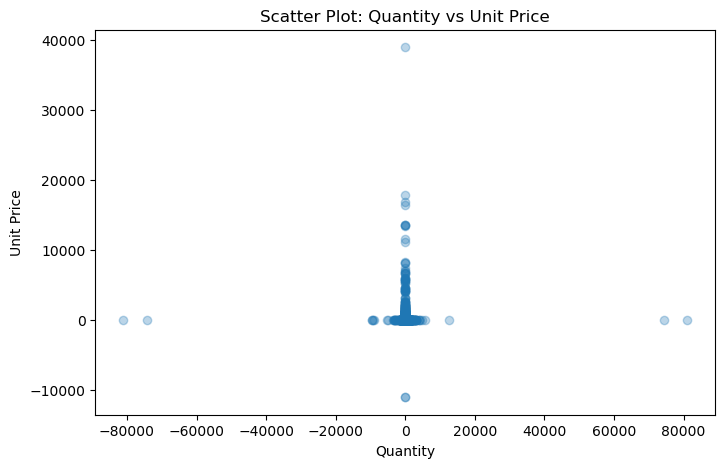

In [476]:
plt.figure(figsize=(8,5))
plt.scatter(data['Quantity'], data['UnitPrice'], alpha=0.3)
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.title("Scatter Plot: Quantity vs Unit Price")
plt.show()

In [477]:
# Count missing values per column
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## 🔍 Key Observations

From the initial exploration of the dataset:

- The dataset contains a large number of transactions.
- Missing values exist in the `Description` and `CustomerID` columns.
- Negative values are present in `Quantity` and `UnitPrice`, likely representing product returns or data errors.
- Significant outliers exist in both quantity and pricing data.
- Certain columns may require type conversion (InvoiceDate).

These issues will be addressed during the data cleaning phase.


## 🧹 Data Cleaning

Before performing analysis, it is essential to clean the dataset to ensure accuracy and consistency.

In this step, we will:

- Handle missing values
- Remove invalid or irrelevant data
- Convert data types where necessary
- Create new features for analysis


In [478]:
# Remove rows with missing CustomerID
data = data.dropna(subset=['CustomerID'])

In [479]:
# Keep only positive quantities
data = data[data['Quantity'] > 0]

# Keep only positive prices
data = data[data['UnitPrice'] > 0]

In [480]:
# Convert InvoiceDate to datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

## 🚨 Outlier Handling

Extreme values were identified in Quantity and UnitPrice.

These values are significantly higher than the normal range and can distort analysis.

Outliers were removed to ensure more reliable and realistic insights.


In [481]:
# Remove extreme Quantity values
data = data[data['Quantity'] < 100]

# Remove extreme UnitPrice values
data = data[data['UnitPrice'] < 50]

In [482]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,391048.000000,391048,391048.000000,391048.000000
mean,9.218398,2011-07-11 03:31:09.530543,2.887886,15295.366566
min,1.000000,2010-12-01 08:26:00,0.001000,12347.000000
25%,2.000000,2011-04-07 11:16:00,1.250000,13969.000000
50%,5.000000,2011-07-31 15:24:00,1.950000,15159.000000
75%,12.000000,2011-10-20 19:51:00,3.750000,16800.000000
max,98.000000,2011-12-09 12:50:00,49.950000,18287.000000
std,12.336835,NaN,3.099324,1712.766760


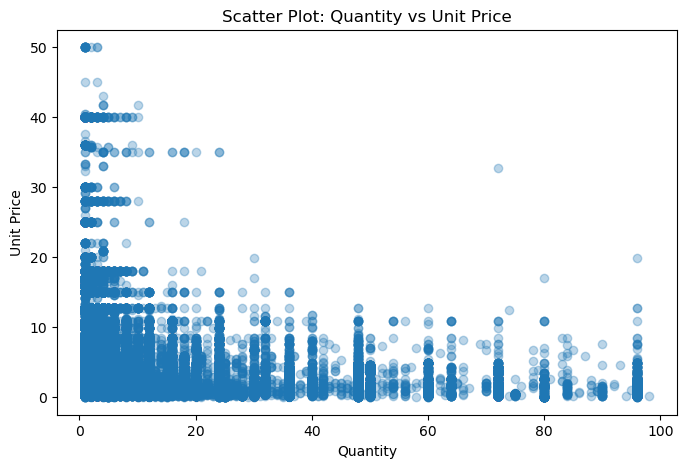

In [483]:
plt.figure(figsize=(8,5))
plt.scatter(data['Quantity'], data['UnitPrice'], alpha=0.3)
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.title("Scatter Plot: Quantity vs Unit Price")
plt.show()

## 📊 Outlier Analysis

After removing extreme outliers, the data shows a clear and realistic distribution.

- Most transactions involve low quantities and low unit prices
- Some higher-value transactions remain, representing bulk purchases or premium products

The dataset is now clean and suitable for reliable analysis.


In [484]:
# Create Revenue column
data['Revenue'] = data['Quantity'] * data['UnitPrice']

In [486]:
# Display the first 5 rows of the cleaned dataset
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [487]:
# Get descriptive statistics for the cleaned dataset
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,391048.000000,391048,391048.000000,391048.000000,391048.000000
mean,9.218398,2011-07-11 03:31:09.530543,2.887886,15295.366566,17.061987
min,1.000000,2010-12-01 08:26:00,0.001000,12347.000000,0.001000
25%,2.000000,2011-04-07 11:16:00,1.250000,13969.000000,4.560000
50%,5.000000,2011-07-31 15:24:00,1.950000,15159.000000,11.400000
75%,12.000000,2011-10-20 19:51:00,3.750000,16800.000000,18.600000
max,98.000000,2011-12-09 12:50:00,49.950000,18287.000000,2353.680000
std,12.336835,NaN,3.099324,1712.766760,27.515900


In [488]:
data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

In [495]:
data.to_csv("../data/cleaned_data.csv", index=False)

## Data Cleaning Summary

The dataset was cleaned by:

- Removing rows with missing CustomerID values
- Filtering out negative quantities and prices
- Converting InvoiceDate to datetime format
- Creating a Revenue column for analysis

The dataset is now ready for accurate and meaningful analysis.
